# Batch gradient descent

In [337]:
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time

In [338]:
X,y = load_diabetes(return_X_y=True)

In [339]:
diabetes = load_diabetes()
df = pd.DataFrame(
    diabetes.data,
    columns = diabetes.feature_names
)
df["target"] = diabetes.target

In [340]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [341]:
df.shape

(442, 11)

In [342]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [343]:
df.corr()["target"]

age       0.187889
sex       0.043062
bmi       0.586450
bp        0.441482
s1        0.212022
s2        0.174054
s3       -0.394789
s4        0.430453
s5        0.565883
s6        0.382483
target    1.000000
Name: target, dtype: float64

In [344]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [345]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [346]:
model.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [347]:
model.intercept_

np.float64(151.88331005254167)

In [348]:
y_pred=model.predict(X_test)
print("R2 score for testing:",r2_score(y_test,y_pred))

y_pred1 = model.predict(X_train)
print("R2 score for training:",r2_score(y_train,y_pred1))

R2 score for testing: 0.4399338661568968
R2 score for training: 0.5323672232993288


In [349]:
class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):

        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
            self.intercept_ = 0
            self.coef_ = np.ones(X_train.shape[1])
            print(self.intercept_ , self.coef_)

            for i in range(self.epochs):
                y_hat = np.dot(X_train,self.coef_) + self.intercept_
                # print("shape of y_hat" ,y_hat.shape)
                intercept_der = -2 * np.mean(y_train - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 *np.dot((y_train-y_hat),X_train)/X_train.shape[0]
                self.coef_ = self.coef_ - (self.lr * coef_der)

    def predict(self,X_test):
            return np.dot(X_test,self.coef_)+self.intercept_

In [350]:
gdr = GDRegressor(epochs=100, learning_rate=0.8)

In [351]:
start = time.time()
gdr.fit(X_train,y_train)
print("Time taken is ",time.time()-start)


0 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Time taken is  0.0029947757720947266


In [352]:
print(gdr.intercept_)
print(gdr.coef_)

151.8286128684468
[  60.40735282  -13.56544847  229.21430506  169.82286965   42.75871732
   18.72579651 -128.1841865   116.85243208  215.50917357  110.76382624]


In [353]:
z_pred = gdr.predict(X_test)
z_pred1 = gdr.predict(X_train)


In [354]:
print("R2 score for testing:",r2_score(y_test,z_pred))
print("R2 score for training:",r2_score(y_train,z_pred1))

R2 score for testing: 0.37689929761677976
R2 score for training: 0.4085259387030261


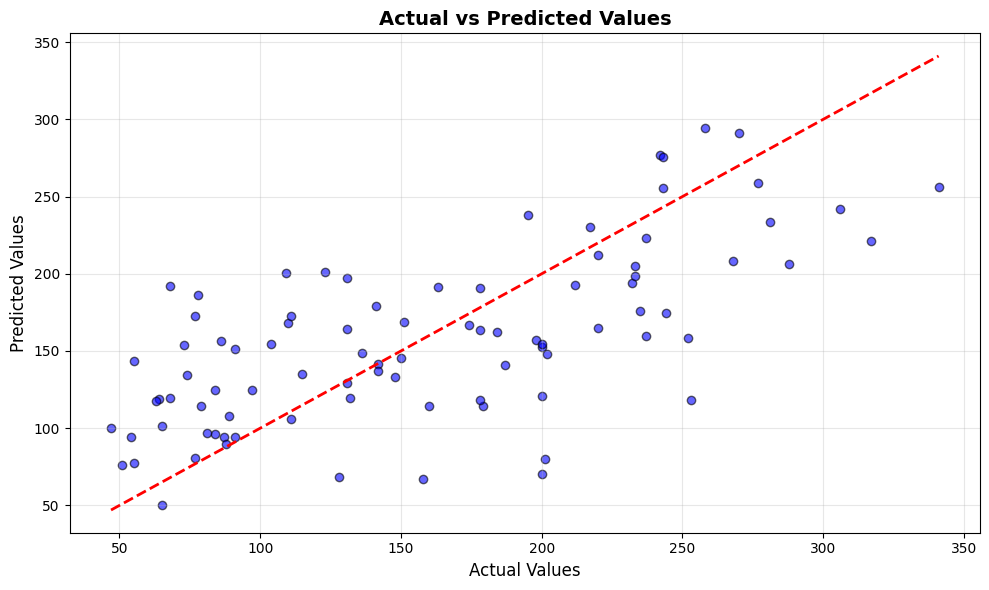

In [355]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
